In [2]:
import pandas as pd
from codes.plots import plot_vehicle_duration_hist, plot_stop_histogram_percentage
df = pd.read_csv("data/2024_11_17_17_00.csv", sep=",", header = None ,names=["year","month","day","hour","id","vehicle_id","timestamp","time","lat","lon","speed","course" ])

Data already sorted and without missing values

In [3]:
df['timestamp'].is_monotonic_increasing

True

In [13]:
len(df)

81732

In [16]:
len(df["id"].unique())

2045

In [4]:
df.isna().sum()

year          0
month         0
day           0
hour          0
id            0
vehicle_id    0
timestamp     0
time          0
lat           0
lon           0
speed         0
course        0
dtype: int64

Typical data from a single vehicle

In [10]:
df[df["vehicle_id"] == "a27b6f756ac59d57bbe4921acb753a92de74b5decbc42c9b4d2b63f14807c52c"]

,year,month,day,hour,id,vehicle_id,timestamp,time,lat,lon,speed,course
56,2024,11,17,17,21090985,a27b6f756ac59d57bbe4921acb753a92de74b5decbc42c...,1731859200,2024-11-17 17:00:00,20.99429,52.27692,82,342
290,2024,11,17,17,21840716,a27b6f756ac59d57bbe4921acb753a92de74b5decbc42c...,1731859210,2024-11-17 17:00:10,20.99336,52.27878,75,342
516,2024,11,17,17,21815664,a27b6f756ac59d57bbe4921acb753a92de74b5decbc42c...,1731859220,2024-11-17 17:00:20,20.99225,52.28068,82,336
742,2024,11,17,17,21087641,a27b6f756ac59d57bbe4921acb753a92de74b5decbc42c...,1731859230,2024-11-17 17:00:30,20.99101,52.28246,68,342
962,2024,11,17,17,21087805,a27b6f756ac59d57bbe4921acb753a92de74b5decbc42c...,1731859240,2024-11-17 17:00:40,20.99011,52.28371,43,326
1183,2024,11,17,17,21087819,a27b6f756ac59d57bbe4921acb753a92de74b5decbc42c...,1731859250,2024-11-17 17:00:50,20.98982,52.28458,39,34
1406,2024,11,17,17,16881814,a27b6f756ac59d57bbe4921acb753a92de74b5decbc42c...,1731859260,2024-11-17 17:01:00,20.99152,52.28541,64,50
1629,2024,11,17,17,16881814,a27b6f756ac59d57bbe4921acb753a92de74b5decbc42c...,1731859270,2024-11-17 17:01:10,20.99406,52.28661,90,52
1847,2024,11,17,17,16893353,a27b6f756ac59d57bbe4921acb753a92de74b5decbc42c...,1731859280,2024-11-17 17:01:20,20.99687,52.28789,72,52
2079,2024,11,17,17,22640268,a27b6f756ac59d57bbe4921acb753a92de74b5decbc42c...,1731859290,2024-11-17 17:01:30,20.99902,52.28887,64,52


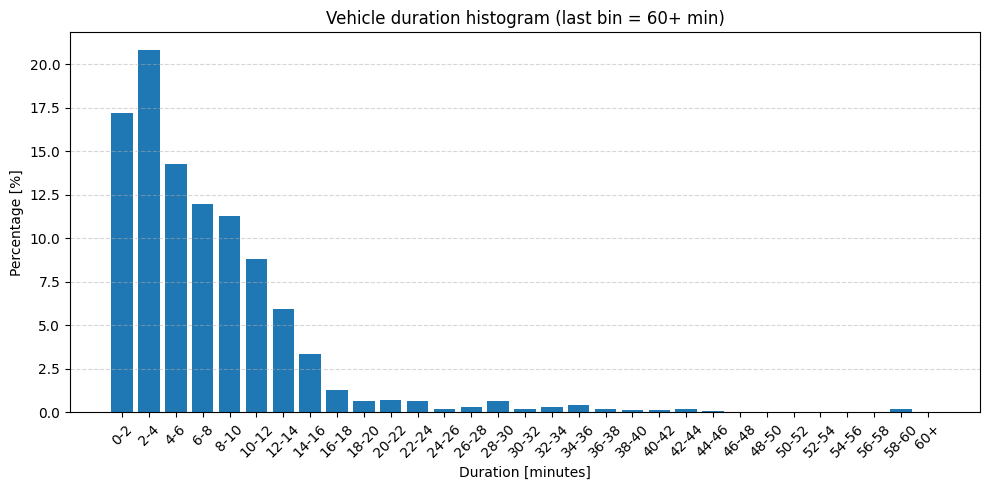

In [6]:
_= plot_vehicle_duration_hist(df)

Most of the users, use application less than 10 minutes. We have to decide the threshold after which we consider proper route.

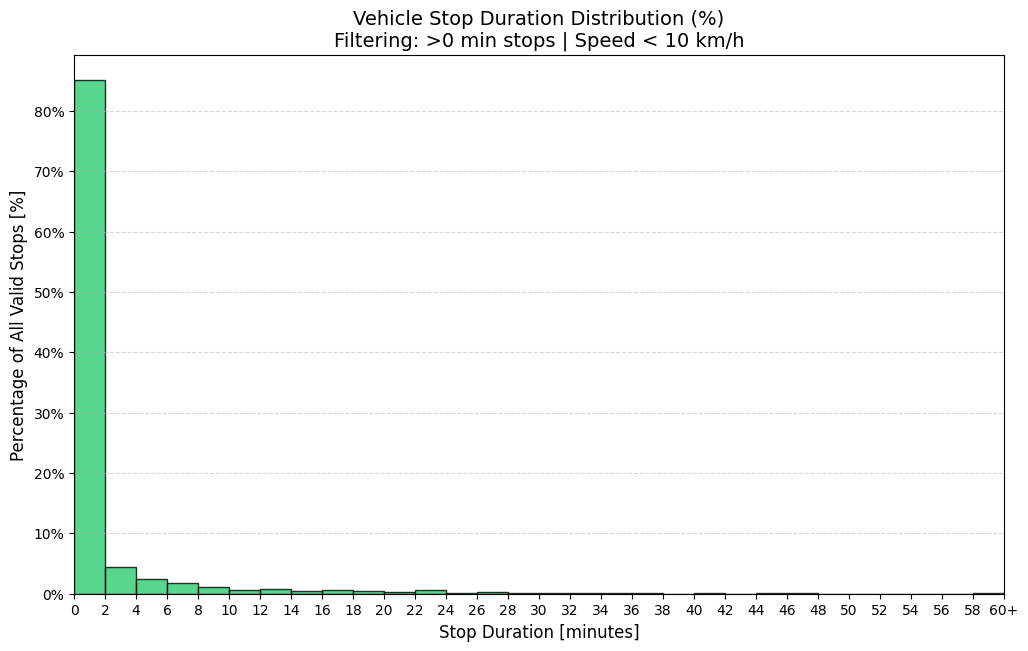

Total stops analyzed: 2012
Stops after filtering (<0 min removed): 2012
Median stop duration: 0.38 minutes


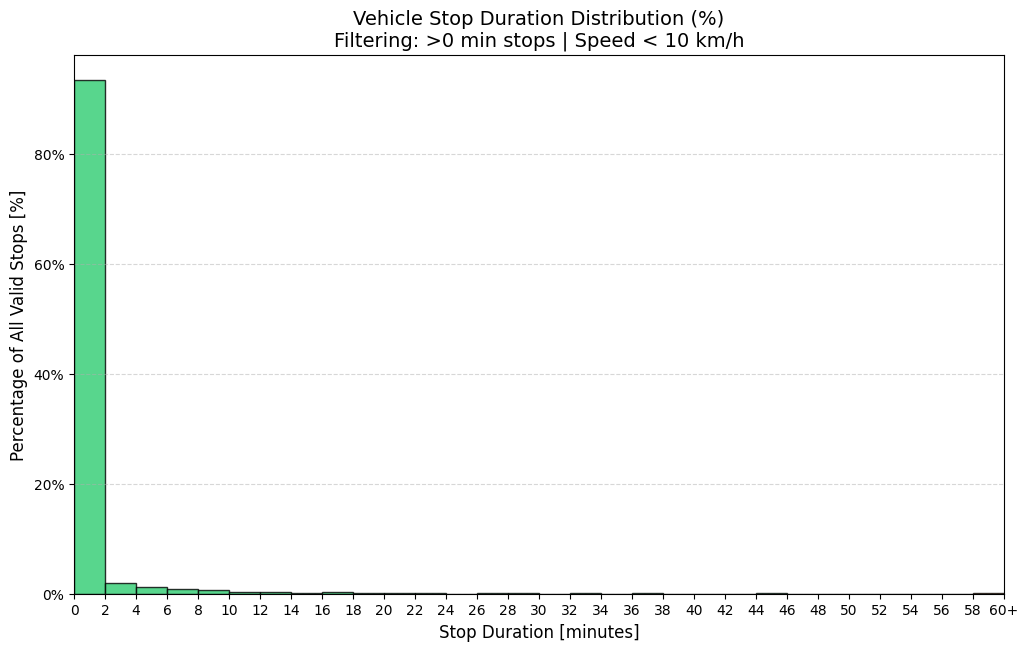

Total stops analyzed: 1761
Stops after filtering (<0 min removed): 1761
Median stop duration: 0.18 minutes


In [7]:
_ = plot_stop_histogram_percentage(df,include_gaps=True, min_stop_min=0, gap_threshold_sec=60, max_limit_min=60)
_ = plot_stop_histogram_percentage(df,include_gaps=False, min_stop_min=0, gap_threshold_sec=60, max_limit_min=60)

Majority of stops are fake and caused by traffic lights. Also we have to decide thresholds values and whether we treat gaps in messurment as stops or under which conditions

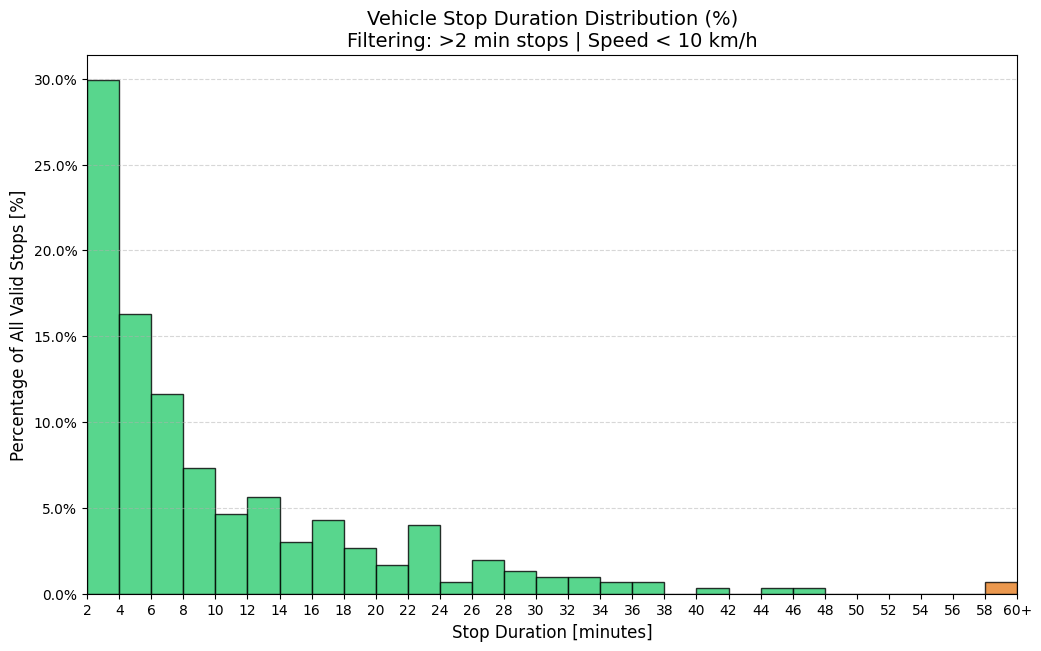

Total stops analyzed: 2012
Stops after filtering (<2 min removed): 301
Median stop duration: 6.48 minutes


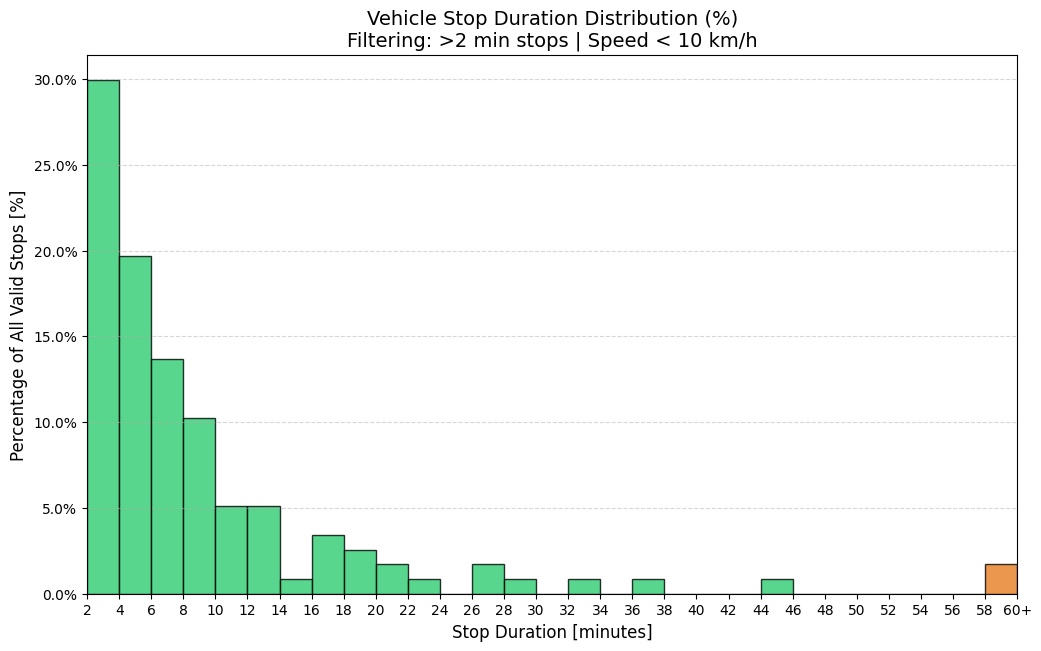

Total stops analyzed: 1761
Stops after filtering (<2 min removed): 117
Median stop duration: 6.03 minutes


In [9]:
_ = plot_stop_histogram_percentage(df,include_gaps=True, min_stop_min=2, gap_threshold_sec=60, max_limit_min=60)
_ = plot_stop_histogram_percentage(df,include_gaps=False, min_stop_min=2, gap_threshold_sec=60, max_limit_min=60)